In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec


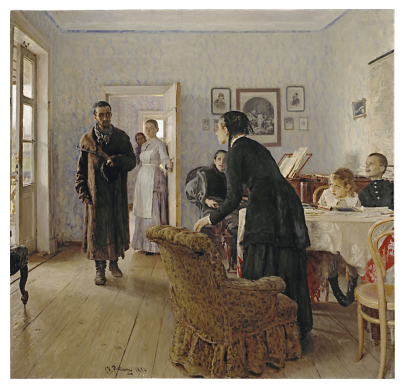

In [3]:
img = cv2.imread('Ilya_Repin_Unexpected_visitors.jpg', cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

#### 1. Построить гистограмму серого изображения и найти пик интенсивности с наибольшим количеством пикселей.

Пик интенсивности: уровень яркости = 165
Количество пикселей с этой яркостью = 98054


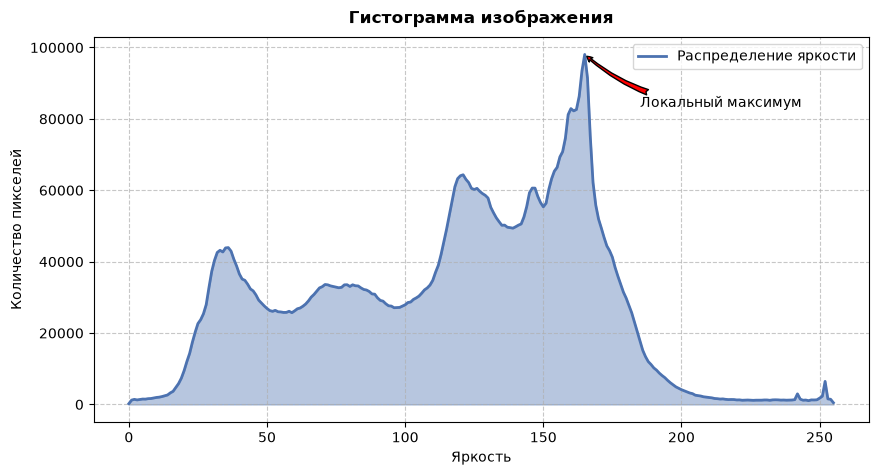

In [4]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

# 2. Находим пик серости и количество пикселей в этом пике
peak_brightness = np.argmax(hist)

peak_count = int(hist[peak_brightness])

print(f"Пик интенсивности: уровень яркости = {peak_brightness}")
print(f"Количество пикселей с этой яркостью = {peak_count}")

plt.figure(figsize=(10, 5), dpi=100)

x_axis = np.arange(256)
plt.plot(x_axis, hist, color="#4c72b0", linewidth=2, label='Распределение яркости')
plt.fill_between(x_axis, hist, color="#4c72b0", alpha=0.4)

plt.annotate(
    'Локальный максимум', 
    xy=(peak_brightness, peak_count), 
    xytext=(peak_brightness + 20, peak_count - (peak_count * 0.15)), 
    arrowprops=dict(arrowstyle='fancy', facecolor='red', connectionstyle="arc3,rad=-0.2"))

plt.title('Гистограмма изображения', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Яркость', fontsize=10)
plt.ylabel('Количество пикселей', fontsize=10)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

#### 2. Построить профили изображения после применения фильтра Лапласа.

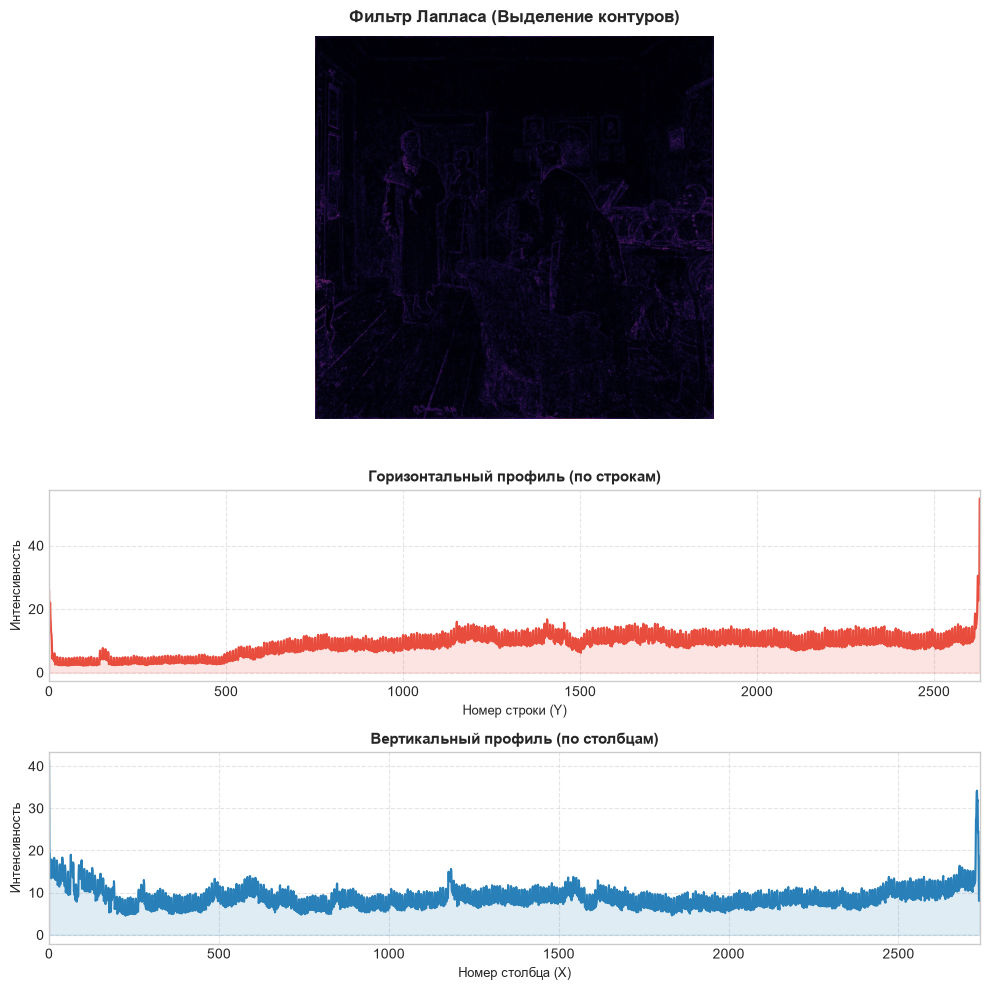

In [5]:
# Используем cv2.CV_64F, чтобы избежать переполнения при вычислении градиентов,
laplacian_raw = cv2.Laplacian(img_gray, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian_raw))

# Вычисляем профили
horizontal_profile = np.mean(laplacian, axis=1) # по строкам
vertical_profile = np.mean(laplacian, axis=0)   # по столбцам

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1, 1]})

# Изображение Лапласа
ax1.imshow(laplacian, cmap='magma')
ax1.set_title('Фильтр Лапласа (Выделение контуров)', fontsize=12, fontweight='bold', pad=10)
ax1.axis('off')

# Горизонтальный профиль
ax2.plot(horizontal_profile, color='#e74c3c', linewidth=1.5, label='Средняя яркость')
ax2.fill_between(range(len(horizontal_profile)), horizontal_profile, color='#e74c3c', alpha=0.15)
ax2.set_title('Горизонтальный профиль (по строкам)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Номер строки (Y)', fontsize=9)
ax2.set_ylabel('Интенсивность', fontsize=9)
ax2.set_xlim([0, len(horizontal_profile)])
ax2.grid(True, linestyle='--', alpha=0.5)

# Вертикальный профиль
ax3.plot(vertical_profile, color='#2980b9', linewidth=1.5, label='Средняя яркость')
ax3.fill_between(range(len(vertical_profile)), vertical_profile, color='#2980b9', alpha=0.15)
ax3.set_title('Вертикальный профиль (по столбцам)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Номер столбца (X)', fontsize=9)
ax3.set_ylabel('Интенсивность', fontsize=9)
ax3.set_xlim([0, len(vertical_profile)])
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 3. Построить горизонтальную проекцию и определить строки с максимумом интенсивности.
#### 4. Построить вертикальную проекцию и определить столбцы с максимумом интенсивности.

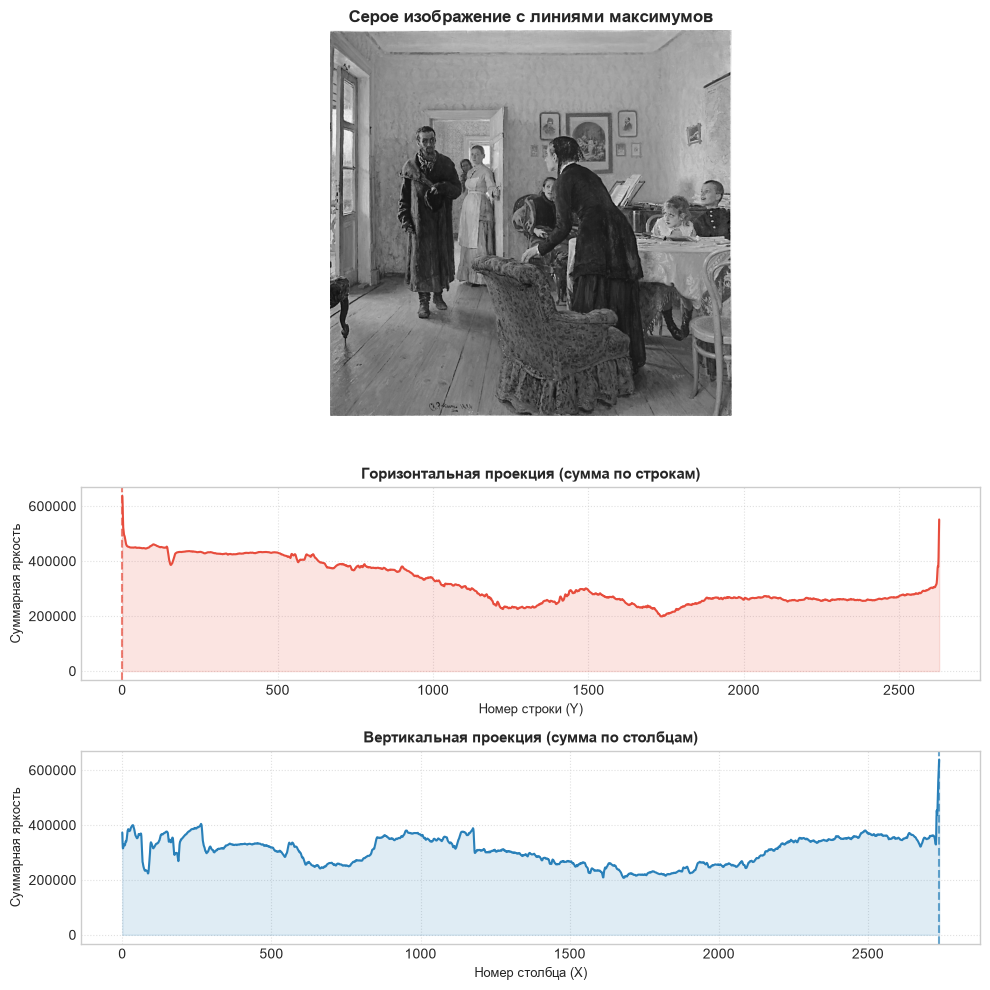

Строка с максимумом интенсивности: 0
Столбец с максимумом интенсивности: 2739


In [6]:
horizontal_projection = np.sum(img_gray, axis=1) # по строкам
vertical_projection = np.sum(img_gray, axis=0)   # по столбцам

max_row_idx = np.argmax(horizontal_projection)
max_col_idx = np.argmax(vertical_projection)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1, 1]})

# Исходное изображение с отмеченными линиями максимумов
ax1.imshow(img_gray, cmap='gray')
ax1.set_title('Серое изображение с линиями максимумов', fontsize=12, fontweight='bold')
ax1.axis('off')

# Горизонтальная проекция
ax2.plot(horizontal_projection, color='#e74c3c', linewidth=1.5)
ax2.axvline(x=max_row_idx, color='#e74c3c', linestyle='--', alpha=0.7)
ax2.fill_between(range(len(horizontal_projection)), horizontal_projection, color='#e74c3c', alpha=0.15)
ax2.set_title('Горизонтальная проекция (сумма по строкам)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Номер строки (Y)', fontsize=9)
ax2.set_ylabel('Суммарная яркость', fontsize=9)
ax2.grid(True, linestyle=':', alpha=0.6)

# Вертикальная проекция
ax3.plot(vertical_projection, color='#2980b9', linewidth=1.5)
ax3.axvline(x=max_col_idx, color='#2980b9', linestyle='--', alpha=0.7)
ax3.fill_between(range(len(vertical_projection)), vertical_projection, color='#2980b9', alpha=0.15)
ax3.set_title('Вертикальная проекция (сумма по столбцам)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Номер столбца (X)', fontsize=9)
ax3.set_ylabel('Суммарная яркость', fontsize=9)
ax3.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Строка с максимумом интенсивности: {max_row_idx}")
print(f"Столбец с максимумом интенсивности: {max_col_idx}")

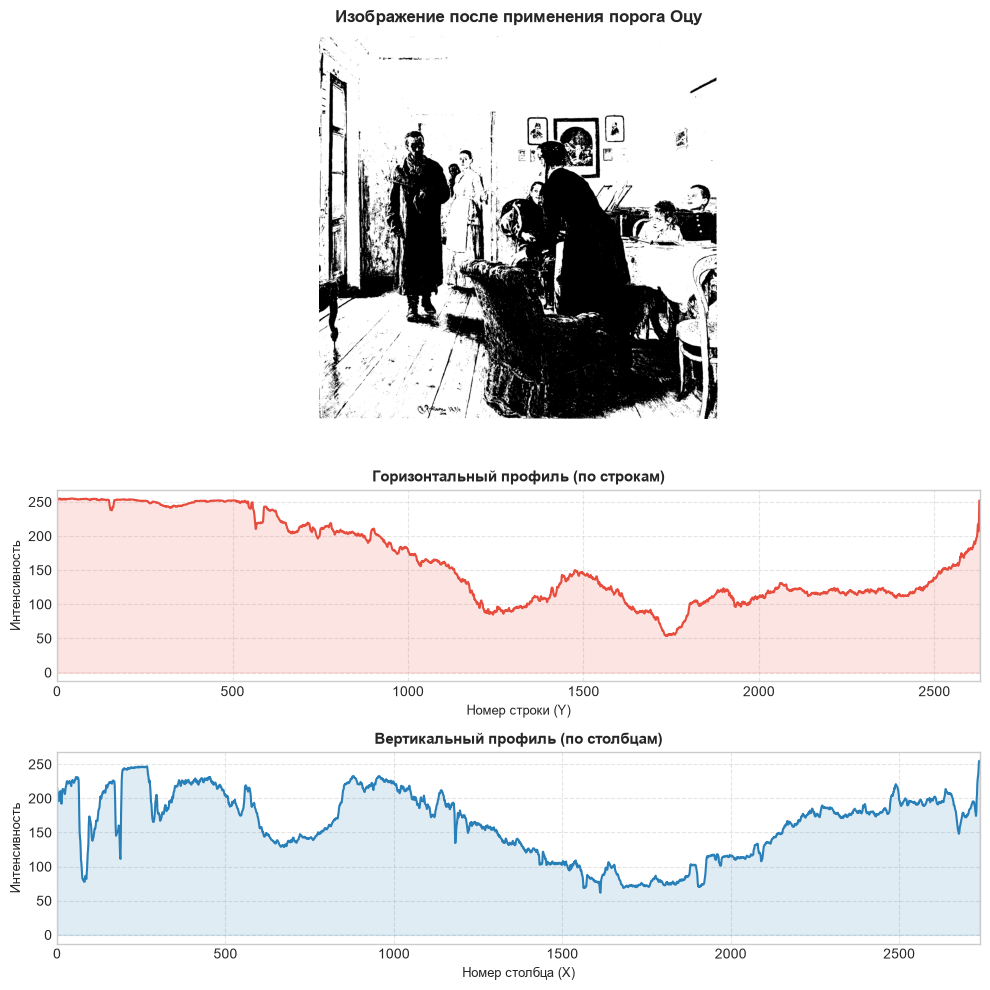

Автоматически найденный порог Оцу: 104.0


In [9]:
val, otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Вычисляем профили
horizontal_profile = np.mean(otsu, axis=1) # по строкам
vertical_profile = np.mean(otsu, axis=0)   # по столбцам

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1, 1]})

# Изображение Оцу
ax1.imshow(otsu, cmap='gray')
ax1.set_title('Изображение после применения порога Оцу', fontsize=12, fontweight='bold', pad=10)
ax1.axis('off')

# Горизонтальный профиль
ax2.plot(horizontal_profile, color='#e74c3c', linewidth=1.5, label='Средняя яркость')
ax2.fill_between(range(len(horizontal_profile)), horizontal_profile, color='#e74c3c', alpha=0.15)
ax2.set_title('Горизонтальный профиль (по строкам)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Номер строки (Y)', fontsize=9)
ax2.set_ylabel('Интенсивность', fontsize=9)
ax2.set_xlim([0, len(horizontal_profile)])
ax2.grid(True, linestyle='--', alpha=0.5)

# Вертикальный профиль
ax3.plot(vertical_profile, color='#2980b9', linewidth=1.5, label='Средняя яркость')
ax3.fill_between(range(len(vertical_profile)), vertical_profile, color='#2980b9', alpha=0.15)
ax3.set_title('Вертикальный профиль (по столбцам)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Номер столбца (X)', fontsize=9)
ax3.set_ylabel('Интенсивность', fontsize=9)
ax3.set_xlim([0, len(vertical_profile)])
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Автоматически найденный порог Оцу: {val}")


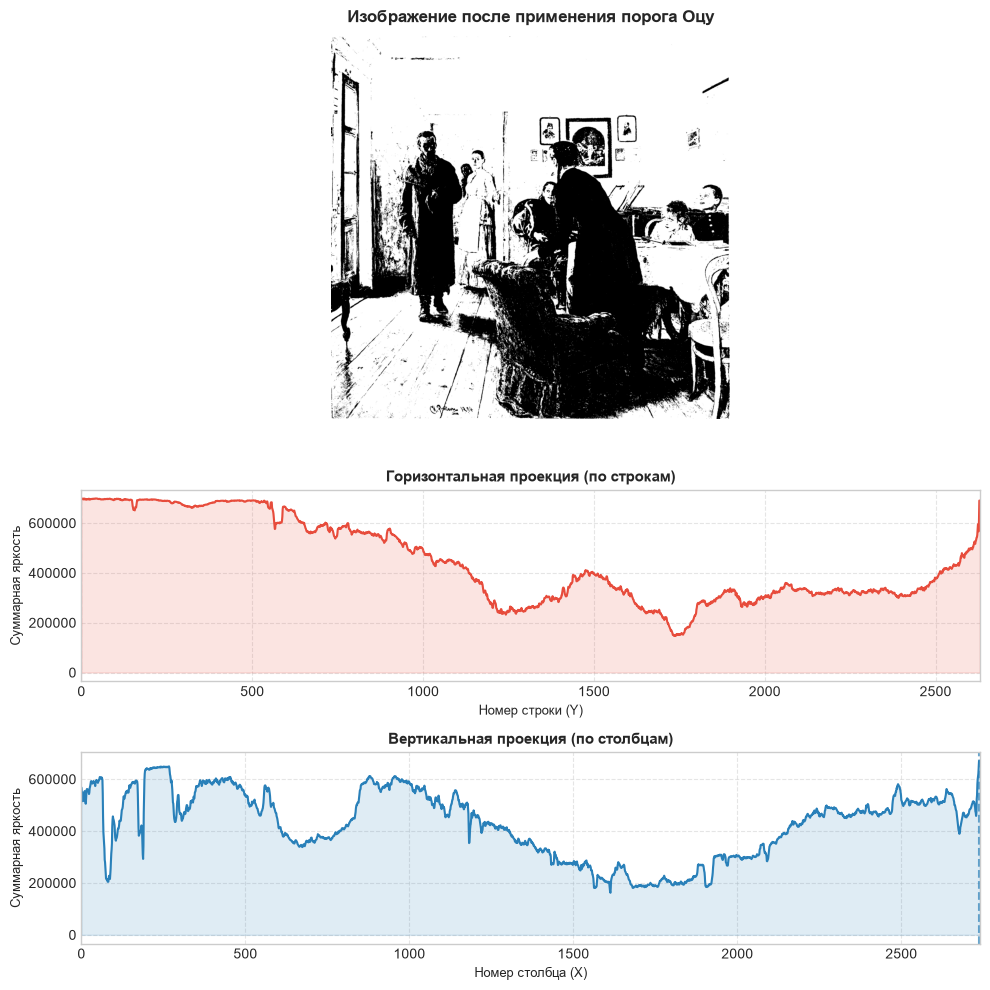

Строка с максимумом интенсивности: 0
Столбец с максимумом интенсивности: 2738


In [ ]:
horizontal_projection = np.sum(otsu, axis=1) # по строкам
vertical_projection = np.sum(otsu, axis=0)   # по столбцам

max_row_idx = np.argmax(horizontal_projection)
max_col_idx = np.argmax(vertical_projection)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1, 1]})

ax1.imshow(otsu, cmap='gray')
ax1.set_title('Изображение после применения порога Оцу', fontsize=12, fontweight='bold', pad=10)
ax1.axis('off')

ax2.plot(horizontal_projection, color='#e74c3c', linewidth=1.5, label='Суммарная яркость')
ax2.axvline(x=max_row_idx, color='#e74c3c', linestyle='--', alpha=0.7)
ax2.fill_between(range(len(horizontal_projection)), horizontal_projection, color='#e74c3c', alpha=0.15)
ax2.set_title('Горизонтальная проекция (по строкам)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Номер строки (Y)', fontsize=9)
ax2.set_ylabel('Суммарная яркость', fontsize=9)
ax2.set_xlim([0, len(horizontal_projection)])
ax2.grid(True, linestyle='--', alpha=0.5)

ax3.plot(vertical_projection, color='#2980b9', linewidth=1.5, label='Суммарная яркость')
ax3.axvline(x=max_col_idx, color='#2980b9', linestyle='--', alpha=0.7)
ax3.fill_between(range(len(vertical_projection)), vertical_projection, color='#2980b9', alpha=0.15)
ax3.set_title('Вертикальная проекция (по столбцам)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Номер столбца (X)', fontsize=9)
ax3.set_ylabel('Суммарная яркость', fontsize=9)
ax3.set_xlim([0, len(vertical_projection)])
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Строка с максимумом интенсивности: {max_row_idx}")
print(f"Столбец с максимумом интенсивности: {max_col_idx}")

#### Ответы на вопросы

1. **Гистограмма изображения** - это график распределения количества пикселей по уровням яркости (от 0 до 255). Она используется для анализа контрастности, освещенности изображения и выбора порогов при бинаризации.

2. **Гистограмма цветного изображения отличается** от серого тем, что в ней для градаций серого строится один график (яркость), а для цветного изображения (RGB) строятся три отдельные гистограммы — по одной для каждого цветового канала (R, G, B).

3. **Профиль изображения** - это одномерный массив, показывающий среднее значение яркости пикселей вдоль выбранного направления (строк или столбцов).

4. **Горизонтальный и вертикальный профиль вычисляются по следующему приципу:**
    * Горизонтальный профиль: усреднение по строкам
    * Вертикальный профиль: усреднение по столбцам

5. **Проекция изображения** - это одномерный массив, содержащий сумму значений яркости пикселей вдоль строк или столбцов.

6. **Разница между профилем и проекцией** заключается в том, что - проекция вычисляет сумму элементов , а профиль — среднее значение . Графики имеют идентичную форму, но отличаются масштабом по оси Y.

7. **Гистограмма помогает в улучшении контраста** так как, по ней видно, занят ли весь диапазон яркостей [0, 255]. Если значения сгруппированы в узкой области, применяется растяжение (эквализация) гистограммы, распределяющее яркости по всему диапазону для повышения контрастности.

8. **Горизонтальные и вертикальные проекции бинарного изображения можно использовать** для сегментации и анализа формы: поиск границ объектов, разделение текста на отдельные строки и слова, определение положения предметов.

9. **После применения фильтра сглаживания** на гистограмме уберутся шумы и резкие перепады яркостей. В результате изолированные острые пики на гистограмме сглаживаются и становятся более размытыми.

10. **Пик на гистограмме изображения** показывает уровень яркости, который чаще всего встречается на изображении (например, преобладающий цвет фона или крупного объекта).